In [1]:
#loading the datasets
from google.colab import files

uploaded = files.upload()

Saving customer_support.csv to customer_support.csv
Saving customer_transactions.csv to customer_transactions.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving employee_performance.csv to employee_performance.csv
Saving employees.csv to employees.csv


In [2]:
#reading the datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

employees = pd.read_csv("employees.csv")
employee_performance = pd.read_csv("employee_performance.csv")
customers = pd.read_csv("customers.csv")
customer_transactions = pd.read_csv("customer_transactions.csv")
customer_support = pd.read_csv("customer_support.csv")
data_dictionary = pd.read_csv("data_dictionary.csv")

print("Employees:", employees.shape)
print("Employee Performance:", employee_performance.shape)
print("Customers:", customers.shape)
print("Customer Transactions:", customer_transactions.shape)
print("Customer Support:", customer_support.shape)
print("Data Dictionary:", data_dictionary.shape)

Employees: (8000, 16)
Employee Performance: (24000, 5)
Customers: (12000, 13)
Customer Transactions: (60000, 5)
Customer Support: (24000, 7)
Data Dictionary: (46, 3)


In [3]:
#Check data types and missing values
datasets = {
    "employees": employees,
    "employee_performance": employee_performance,
    "customers": customers,
    "customer_transactions": customer_transactions,
    "customer_support": customer_support
}

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isna().sum())


EMPLOYEES
Employee_ID               int64
Age                       int64
Gender                   object
Department               object
Job_Level                object
Work_Mode                object
Region                   object
Tenure_Years            float64
Annual_Salary           float64
Overtime                 object
Job_Satisfaction          int64
Manager_Satisfaction      int64
Promotions_Last_3Yrs      int64
Training_Hours            int64
Monthly_Hours             int64
Attrition                object
dtype: object

Missing values:
Employee_ID             0
Age                     0
Gender                  0
Department              0
Job_Level               0
Work_Mode               0
Region                  0
Tenure_Years            0
Annual_Salary           0
Overtime                0
Job_Satisfaction        0
Manager_Satisfaction    0
Promotions_Last_3Yrs    0
Training_Hours          0
Monthly_Hours           0
Attrition               0
dtype: int64

EMPLOYEE_PERFORM

In [5]:
#Convering the customer date fields
customer_transactions["Transaction_Date"] = pd.to_datetime(
    customer_transactions["Transaction_Date"]
)

customer_support["Interaction_Date"] = pd.to_datetime(
    customer_support["Interaction_Date"]
)

print("Transaction Date:", customer_transactions["Transaction_Date"].dtype)
print("Interaction Date:", customer_support["Interaction_Date"].dtype)

Transaction Date: datetime64[ns]
Interaction Date: datetime64[ns]


In [6]:
#Creating clean analysis copies
employees_clean = employees[
    employees["Work_Mode"] != "Unknown"
].copy()

customers_clean = customers[
    customers["Payment_Method"] != "Unknown"
].copy()

print("Employees clean:", employees_clean.shape)
print("Customers clean:", customers_clean.shape)

Employees clean: (7945, 16)
Customers clean: (11930, 13)


In [7]:
#HR attrition overview
hr_summary = {
    "Total Employees": len(employees),
    "Average Age": round(employees["Age"].mean(), 1),
    "Average Salary": round(employees["Annual_Salary"].mean(), 0),
    "Average Tenure": round(employees["Tenure_Years"].mean(), 2),
    "Attrition Count": (employees["Attrition"] == "Yes").sum(),
    "Attrition Rate": round(
        (employees["Attrition"] == "Yes").mean() * 100, 2
    )
}

hr_summary

{'Total Employees': 8000,
 'Average Age': np.float64(38.4),
 'Average Salary': np.float64(63153.0),
 'Average Tenure': np.float64(5.51),
 'Attrition Count': np.int64(530),
 'Attrition Rate': np.float64(6.62)}

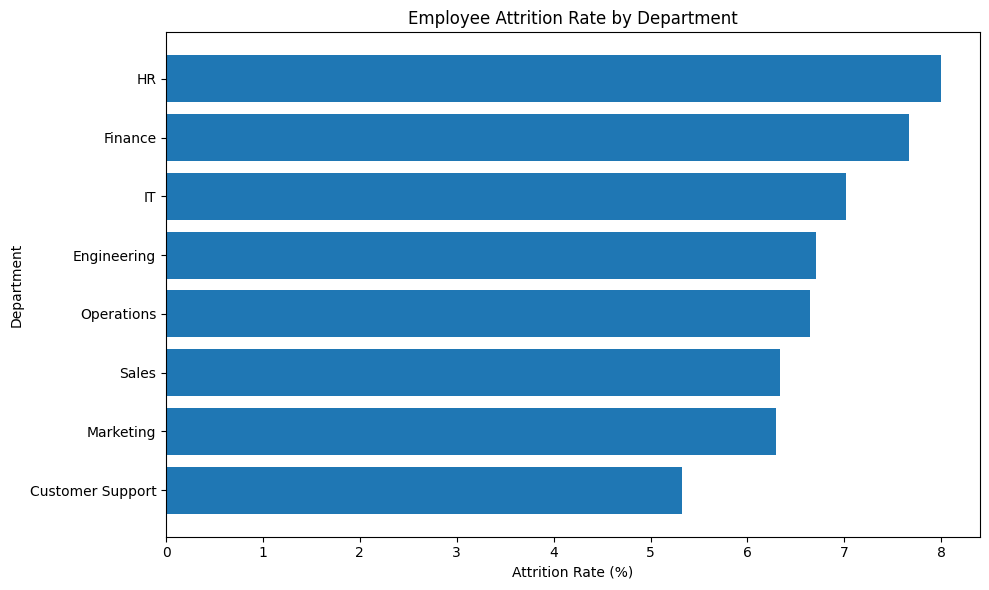

In [8]:
#Attrition Rate by Department
department_attrition = (
    employees_clean.groupby("Department")
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Attrition_Count=("Attrition", lambda x: (x == "Yes").sum())
    )
)

department_attrition["Attrition_Rate"] = (
    department_attrition["Attrition_Count"]
    / department_attrition["Employee_Count"]
    * 100
)

department_attrition = department_attrition.sort_values(
    "Attrition_Rate"
)

plt.figure(figsize=(10, 6))

plt.barh(
    department_attrition.index,
    department_attrition["Attrition_Rate"]
)

plt.title("Employee Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

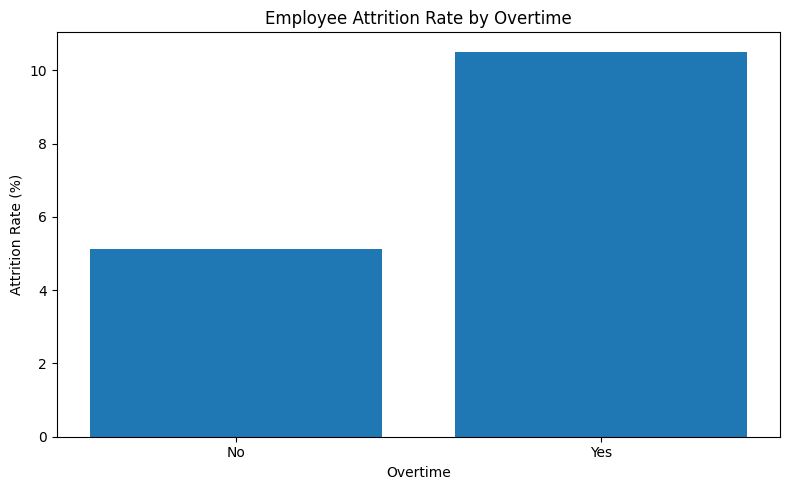

In [10]:
#Attrition by Overtime
overtime_attrition = (
    employees_clean.groupby("Overtime")
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Attrition_Count=("Attrition", lambda x: (x == "Yes").sum())
    )
)

overtime_attrition["Attrition_Rate"] = (
    overtime_attrition["Attrition_Count"]
    / overtime_attrition["Employee_Count"]
    * 100
)

plt.figure(figsize=(8, 5))

plt.bar(
    overtime_attrition.index.astype(str),
    overtime_attrition["Attrition_Rate"]
)

plt.title("Employee Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

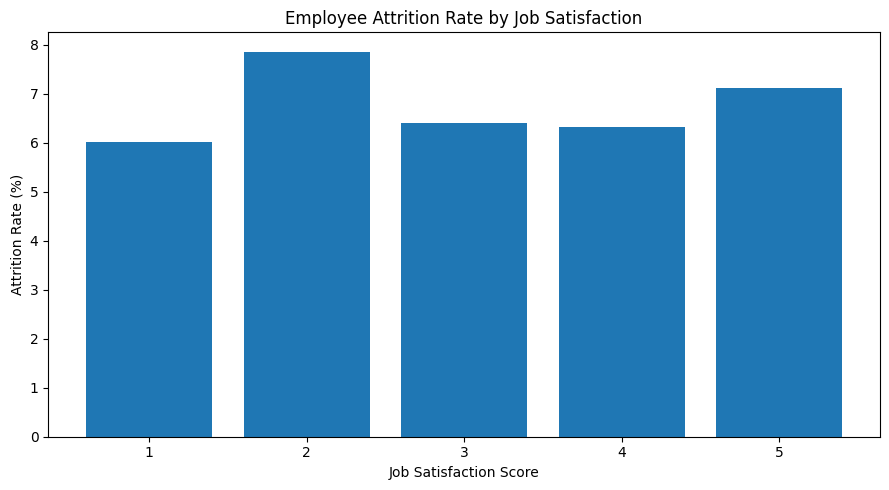

In [11]:
#Attrition by Job Satisfaction
satisfaction_attrition = (
    employees_clean.groupby("Job_Satisfaction")
    .agg(
        Employee_Count=("Employee_ID", "count"),
        Attrition_Count=("Attrition", lambda x: (x == "Yes").sum())
    )
)

satisfaction_attrition["Attrition_Rate"] = (
    satisfaction_attrition["Attrition_Count"]
    / satisfaction_attrition["Employee_Count"]
    * 100
)

plt.figure(figsize=(9, 5))

plt.bar(
    satisfaction_attrition.index.astype(str),
    satisfaction_attrition["Attrition_Rate"]
)

plt.title("Employee Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Score")
plt.ylabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

In [12]:
#Customer Churn Overview
customer_summary = {
    "Total Customers": len(customers),
    "Average Age": round(customers["Age"].mean(), 1),
    "Average Tenure (Months)": round(customers["Tenure_Months"].mean(), 2),
    "Average Monthly Charge": round(customers["Monthly_Charge"].mean(), 2),
    "Churned Customers": (customers["Churn"] == "Yes").sum(),
    "Churn Rate": round(
        (customers["Churn"] == "Yes").mean() * 100, 2
    )
}

customer_summary

{'Total Customers': 12000,
 'Average Age': np.float64(42.3),
 'Average Tenure (Months)': np.float64(28.76),
 'Average Monthly Charge': np.float64(72.31),
 'Churned Customers': np.int64(780),
 'Churn Rate': np.float64(6.5)}

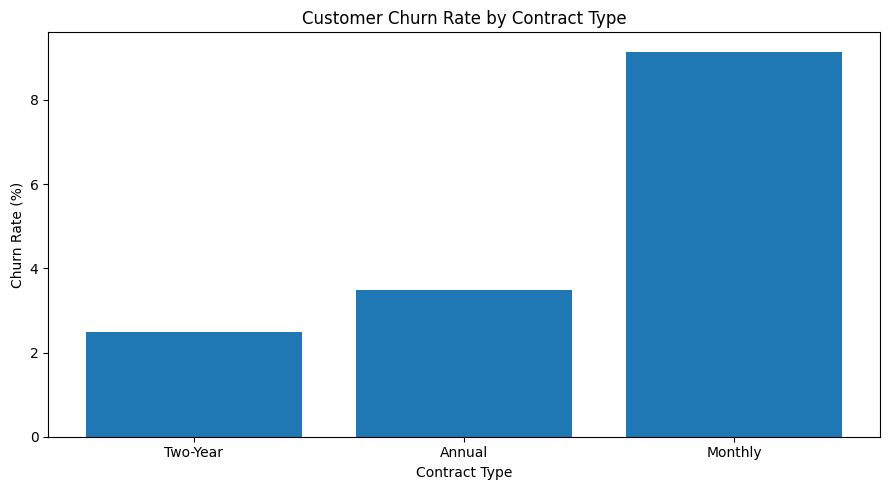

In [13]:
#Churn Rate by Contract Type
contract_churn = (
    customers_clean.groupby("Contract_Type")
    .agg(
        Customer_Count=("Customer_ID", "count"),
        Churn_Count=("Churn", lambda x: (x == "Yes").sum())
    )
)

contract_churn["Churn_Rate"] = (
    contract_churn["Churn_Count"]
    / contract_churn["Customer_Count"]
    * 100
)

contract_churn = contract_churn.sort_values("Churn_Rate")

plt.figure(figsize=(9, 5))

plt.bar(
    contract_churn.index,
    contract_churn["Churn_Rate"]
)

plt.title("Customer Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

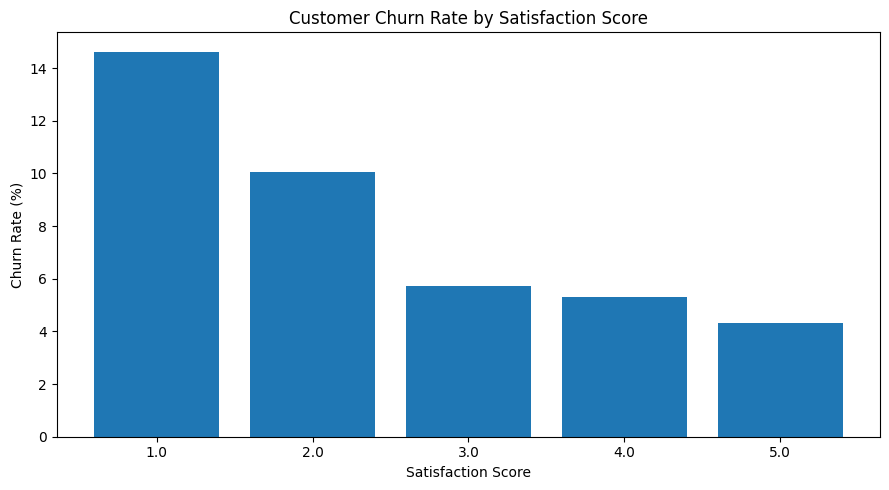

In [15]:
#Churn Rate by Satisfaction
satisfaction_churn = (
    customers_clean.dropna(subset=["Satisfaction_Score"])
    .groupby("Satisfaction_Score")
    .agg(
        Customer_Count=("Customer_ID", "count"),
        Churn_Count=("Churn", lambda x: (x == "Yes").sum())
    )
)

satisfaction_churn["Churn_Rate"] = (
    satisfaction_churn["Churn_Count"]
    / satisfaction_churn["Customer_Count"]
    * 100
)

plt.figure(figsize=(9, 5))

plt.bar(
    satisfaction_churn.index.astype(str),
    satisfaction_churn["Churn_Rate"]
)

plt.title("Customer Churn Rate by Satisfaction Score")
plt.xlabel("Satisfaction Score")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

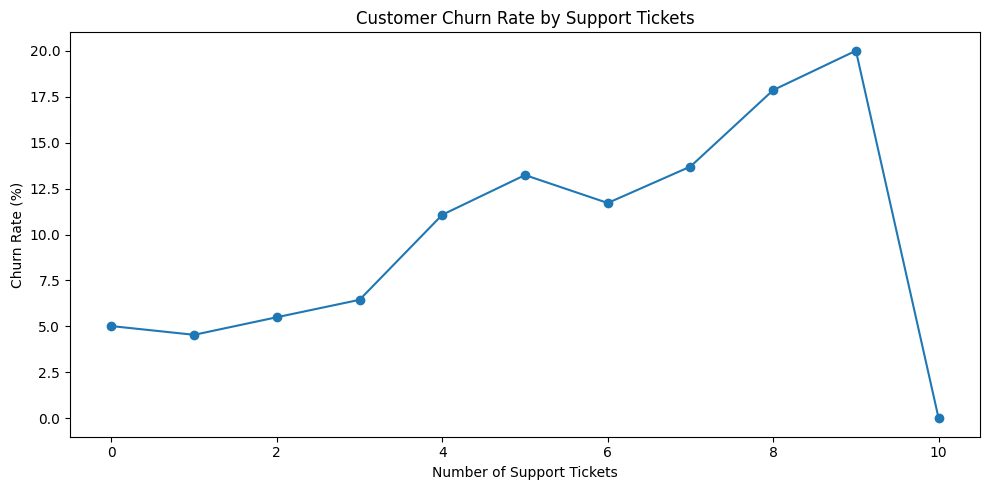

In [16]:
#Churn Rate by Support Tickets
support_churn = (
    customers_clean.groupby("Support_Tickets")
    .agg(
        Customer_Count=("Customer_ID", "count"),
        Churn_Count=("Churn", lambda x: (x == "Yes").sum())
    )
)

support_churn["Churn_Rate"] = (
    support_churn["Churn_Count"]
    / support_churn["Customer_Count"]
    * 100
)

plt.figure(figsize=(10, 5))

plt.plot(
    support_churn.index,
    support_churn["Churn_Rate"],
    marker="o"
)

plt.title("Customer Churn Rate by Support Tickets")
plt.xlabel("Number of Support Tickets")
plt.ylabel("Churn Rate (%)")

plt.tight_layout()
plt.show()

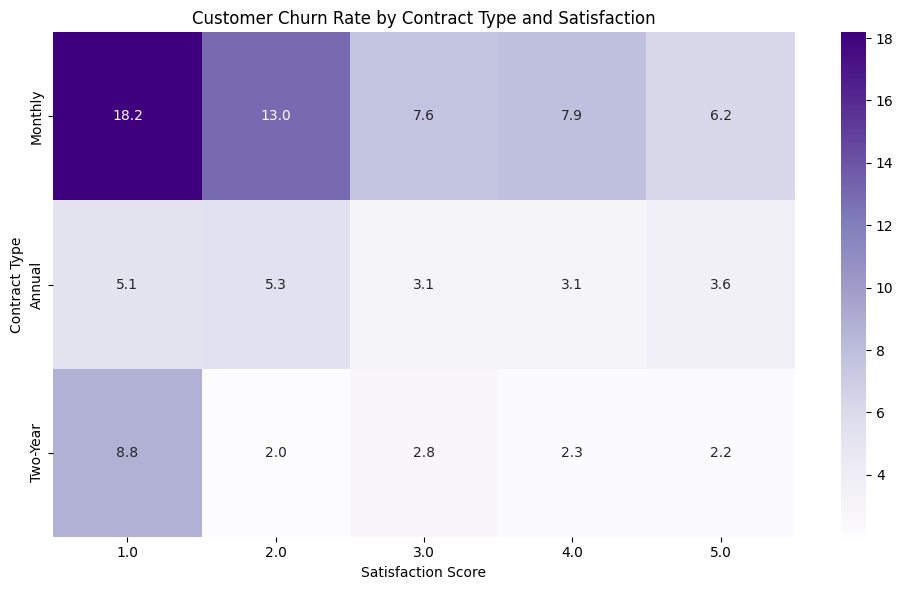

In [17]:
#churn-risk segment heatmap
churn_heatmap = (
    customers_clean
    .dropna(subset=["Satisfaction_Score"])
    .groupby(["Contract_Type", "Satisfaction_Score"])["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .unstack()
)

churn_heatmap = churn_heatmap.reindex(
    ["Monthly", "Annual", "Two-Year"]
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    churn_heatmap,
    annot=True,
    fmt=".1f",
    cmap="Purples"
)

plt.title("Customer Churn Rate by Contract Type and Satisfaction")
plt.xlabel("Satisfaction Score")
plt.ylabel("Contract Type")

plt.tight_layout()
plt.show()

In [18]:
#final summary
final_summary = pd.DataFrame({
    "Metric": [
        "Total Employees",
        "Employee Attrition Rate",
        "Average Employee Tenure",
        "Overtime Attrition Rate",
        "Non-Overtime Attrition Rate",
        "Total Customers",
        "Customer Churn Rate",
        "Average Customer Tenure",
        "Monthly Contract Churn Rate",
        "Annual Contract Churn Rate",
        "Two-Year Contract Churn Rate",
        "High-Risk Customer Churn Rate",
        "Lower-Risk Customer Churn Rate"
    ],
    "Value": [
        len(employees),
        round((employees["Attrition"] == "Yes").mean() * 100, 2),
        round(employees["Tenure_Years"].mean(), 2),
        round(
            employees.loc[employees["Overtime"] == "Yes", "Attrition"]
            .eq("Yes").mean() * 100, 2
        ),
        round(
            employees.loc[employees["Overtime"] == "No", "Attrition"]
            .eq("Yes").mean() * 100, 2
        ),
        len(customers),
        round((customers["Churn"] == "Yes").mean() * 100, 2),
        round(customers["Tenure_Months"].mean(), 2),
        round(
            customers.loc[customers["Contract_Type"] == "Monthly", "Churn"]
            .eq("Yes").mean() * 100, 2
        ),
        round(
            customers.loc[customers["Contract_Type"] == "Annual", "Churn"]
            .eq("Yes").mean() * 100, 2
        ),
        round(
            customers.loc[customers["Contract_Type"] == "Two-Year", "Churn"]
            .eq("Yes").mean() * 100, 2
        ),
        13.82,
        3.82
    ]
})

print(final_summary)

final_summary.to_csv(
    "hr_customer_churn_analysis_summary.csv",
    index=False
)

                            Metric     Value
0                  Total Employees   8000.00
1          Employee Attrition Rate      6.62
2          Average Employee Tenure      5.51
3          Overtime Attrition Rate     10.48
4      Non-Overtime Attrition Rate      5.08
5                  Total Customers  12000.00
6              Customer Churn Rate      6.50
7          Average Customer Tenure     28.76
8      Monthly Contract Churn Rate      9.14
9       Annual Contract Churn Rate      3.49
10    Two-Year Contract Churn Rate      2.48
11   High-Risk Customer Churn Rate     13.82
12  Lower-Risk Customer Churn Rate      3.82
